In [4]:
# Run to install shap and joblib
!pip install shap; joblib; lime

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import shap
import joblib
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


c:\Users\HP\anaconda3\envs\machine-learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Build an RFC model
df = pd.read_csv('data/cleaned_data.csv')

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rfc.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# Tuning the model
parameter_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    param_grid=parameter_grid,
    estimator=rfc,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [8]:
# Viewing the best fitting params
print("Best params: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Extracting the best model
tuned_rfc = grid_search.best_estimator_

Best params:  {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
Best accuracy score:  0.9261194029850746


 99%|===================| 2665/2680 [01:40<00:00]        

X_train shape: (1340, 19)
Number of features: 19
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (1340, 19, 2)


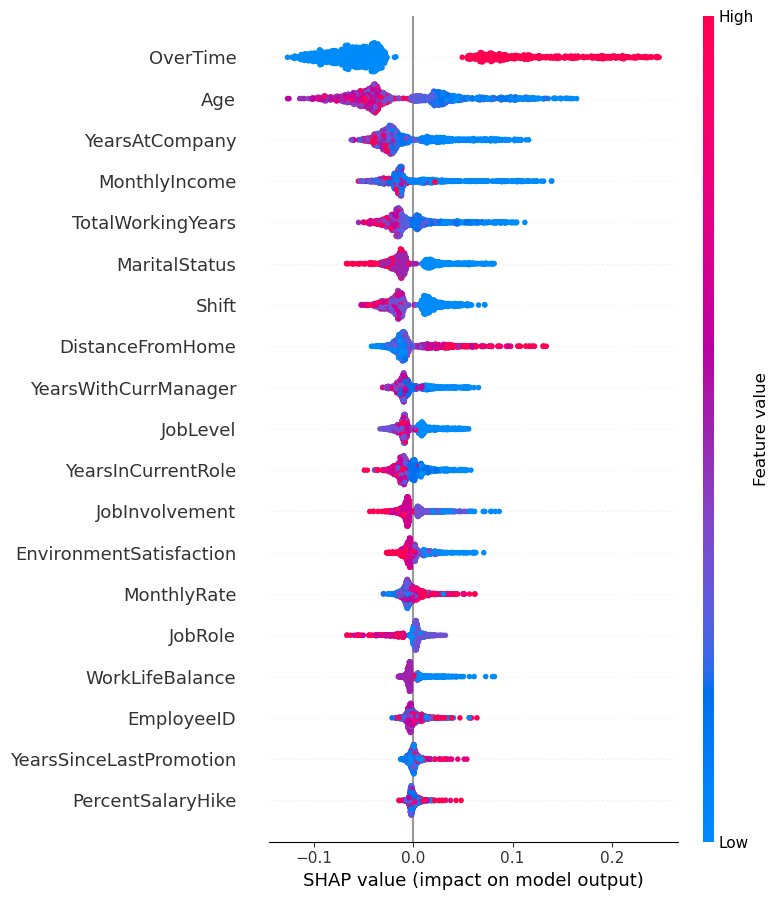

In [9]:
# Compute SHAP values
explainer = shap.TreeExplainer(
    tuned_rfc,
    X_train,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_attrition = shap_values[1]
else:
    shap_attrition = shap_values[:, :, 1]


mean_abs_shap_values = np.abs(shap_attrition).mean(axis=0)

print("X_train shape:", X_train.shape)
print("Number of features:", len(X_train.columns))
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape)

shap_importance = (
    pd.DataFrame({
        'feature': X_train.columns,
        'mean_abs_shap': mean_abs_shap_values
    }).sort_values(by='mean_abs_shap', ascending=False)
)

shap.summary_plot(shap_attrition, X_train)

In [10]:
top_features = shap_importance["feature"].head(5).tolist()
top_features

['OverTime', 'Age', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears']

In [11]:
employee_idx = 0

employee_shap = shap_attrition[employee_idx]

employee_importance = pd.DataFrame({
    "feature": X_train.columns,
    "shap_value": employee_shap,
    "abs_shap": np.abs(employee_shap)
}).sort_values(by="feature", ascending=False)

print(employee_importance.head(10))

                    feature  shap_value  abs_shap
13     YearsWithCurrManager   -0.015214  0.015214
12  YearsSinceLastPromotion   -0.006067  0.006067
11       YearsInCurrentRole   -0.011289  0.011289
6            YearsAtCompany   -0.021702  0.021702
16          WorkLifeBalance    0.028820  0.028820
2         TotalWorkingYears    0.008721  0.008721
15                    Shift    0.013314  0.013314
17        PercentSalaryHike   -0.002196  0.002196
4                  OverTime   -0.067415  0.067415
7               MonthlyRate   -0.004853  0.004853


In [29]:
# Lime 
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['No Attrition', 'Attrition'],
    mode='classification',
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=tuned_rfc.predict_proba,
    num_features=10,
    top_labels=1
)

lime_exp.as_list(label=lime_exp.available_labels()[0])

c:\Users\HP\anaconda3\envs\machine-learning\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[('OverTime <= 0.00', 0.1592629980509487),
 ('YearsAtCompany <= 0.07', -0.04849840233355279),
 ('Age > 43.00', 0.04116920546579158),
 ('TotalWorkingYears > 0.38', 0.024418480080757178),
 ('0.00 < Shift <= 0.33', 0.021468330726376248),
 ('DistanceFromHome <= 0.04', 0.020608937842618247),
 ('0.00 < MaritalStatus <= 1.00', 0.017476822412356607),
 ('YearsWithCurrManager <= 2.00', -0.017437947129176106),
 ('MonthlyIncome > 0.38', 0.01671967744588301),
 ('0.33 < JobInvolvement <= 0.67', 0.016681709123821716)]

In [ ]:
# Jobify
joblib.dump(tuned_rfc, 'rfc_model.joblib')
joblib.dump(X_train.columns.tolist(), 'feature_columns.joblib')

['feature_columns.joblib']

In [27]:
# Evaluation function
def evaluate_model(csv_path, bin_pred, pred_proba):
    # Load saved artifacts
    model = joblib.load('rfc_model.joblib')
    feature_columns = joblib.load('feature_columns.joblib')

    #Load data
    data = pd.read_csv(csv_path)
    X_new = data[feature_columns]

    data['Predicted_Attrition_Proba'] = pred_proba
    data['Predicted_Attrition'] = bin_pred

    new_explainer = shap.TreeExplainer(
        tuned_rfc,
        X_train,
        feature_perturbation="interventional"
    )

    new_shap_values = explainer.shap_values(X_new)

    if isinstance(new_shap_values, list):
        new_shap_attrition = new_shap_values[1]
    else:
        new_shap_attrition = new_shap_values[:, :, 1]

    new_mean_abs_shap_values = np.abs(new_shap_attrition).mean(axis=0)

    shap_influence = (
        pd.DataFrame({
            'feature': X_new.columns,
            'mean_abs_shap': new_mean_abs_shap_values
        }).sort_values(by='mean_abs_shap', ascending=False)
    )

    influential_features = shap_influence['feature'].tolist()
    shap.summary_plot(new_shap_attrition, X_new)

    return influential_features